In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("student_performance 2.csv")

In [3]:
df.shape

(1000000, 6)

In [4]:
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


In [6]:
df['grade'].unique().sum()

'ABCDF'

In [7]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['grade']=le.fit_transform(df['grade'])
df['grade']

0         0
1         1
2         0
3         0
4         0
         ..
999995    0
999996    0
999997    0
999998    0
999999    0
Name: grade, Length: 1000000, dtype: int64

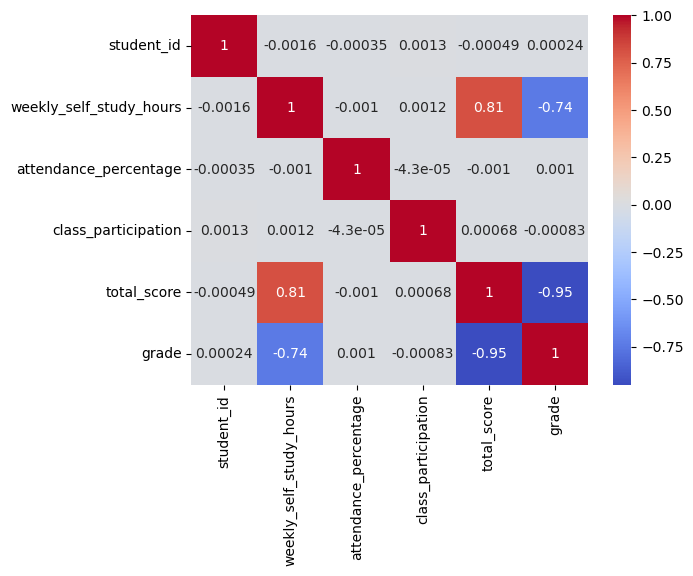

In [8]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [9]:
df.drop('student_id', axis=1, inplace=True)

In [10]:
df.drop('total_score', axis=1, inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   weekly_self_study_hours  1000000 non-null  float64
 1   attendance_percentage    1000000 non-null  float64
 2   class_participation      1000000 non-null  float64
 3   grade                    1000000 non-null  int64  
dtypes: float64(3), int64(1)
memory usage: 30.5 MB


In [12]:
df['engagement_score'] = (
    df['attendance_percentage'] * 0.4 +
    df['class_participation'] * 0.6
)

In [13]:
X = df.drop(['grade'], axis=1)

In [14]:
y = df['grade']

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

In [25]:
df_sample = df.sample(
    100000,
    random_state=42
)

In [29]:
X = df_sample.drop(
    ['grade'],
    axis=1
)

y = df_sample['grade']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.3,

    random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [17]:
##Create a Function to Evaluate Model
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [18]:
models={
    "Logisitic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "Adaboost":AdaBoostClassifier(),
    "Xgboost":XGBClassifier(),
    "KNN Clasifier":KNeighborsClassifier(),
    
    "Naive Bayes":GaussianNB(),
    "XGB Classifier": XGBClassifier(),
    "LGBM Classifier": LGBMClassifier(),
    "CAT Boost Classifier": CatBoostClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred ,  average='weighted') # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred ,  average='weighted') # Calculate Recall



    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred ,  average='weighted') # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred ,  average='weighted') # Calculate Recall



    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
   

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    

    
    print('='*35)
    print('\n')

c:\Users\snrip\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\snrip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\snrip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels wi

Logisitic Regression
Model performance for Training set
- Accuracy: 0.6862
- F1 score: 0.6739
- Precision: 0.6660
- Recall: 0.6862
----------------------------------
Model performance for Test set
- Accuracy: 0.6878
- F1 score: 0.6755
- Precision: 0.6675
- Recall: 0.6878


Decision Tree
Model performance for Training set
- Accuracy: 0.9629
- F1 score: 0.9626
- Precision: 0.9630
- Recall: 0.9629
----------------------------------
Model performance for Test set
- Accuracy: 0.6076
- F1 score: 0.6058
- Precision: 0.6041
- Recall: 0.6076


Random Forest
Model performance for Training set
- Accuracy: 0.9629
- F1 score: 0.9628
- Precision: 0.9628
- Recall: 0.9629
----------------------------------
Model performance for Test set
- Accuracy: 0.6512
- F1 score: 0.6454
- Precision: 0.6407
- Recall: 0.6512


Gradient Boost
Model performance for Training set
- Accuracy: 0.6958
- F1 score: 0.6871
- Precision: 0.6860
- Recall: 0.6958
----------------------------------
Model performance for Test set
-

c:\Users\snrip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\snrip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Adaboost
Model performance for Training set
- Accuracy: 0.6814
- F1 score: 0.6822
- Precision: 0.6848
- Recall: 0.6814
----------------------------------
Model performance for Test set
- Accuracy: 0.6831
- F1 score: 0.6838
- Precision: 0.6863
- Recall: 0.6831


Xgboost
Model performance for Training set
- Accuracy: 0.6987
- F1 score: 0.6907
- Precision: 0.6900
- Recall: 0.6987
----------------------------------
Model performance for Test set
- Accuracy: 0.6962
- F1 score: 0.6882
- Precision: 0.6836
- Recall: 0.6962


KNN Clasifier
Model performance for Training set
- Accuracy: 0.7545
- F1 score: 0.7456
- Precision: 0.7439
- Recall: 0.7545
----------------------------------
Model performance for Test set
- Accuracy: 0.6546
- F1 score: 0.6427
- Precision: 0.6352
- Recall: 0.6546




c:\Users\snrip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\snrip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Naive Bayes
Model performance for Training set
- Accuracy: 0.6947
- F1 score: 0.6903
- Precision: 0.6879
- Recall: 0.6947
----------------------------------
Model performance for Test set
- Accuracy: 0.6962
- F1 score: 0.6918
- Precision: 0.6892
- Recall: 0.6962


XGB Classifier
Model performance for Training set
- Accuracy: 0.6987
- F1 score: 0.6907
- Precision: 0.6900
- Recall: 0.6987
----------------------------------
Model performance for Test set
- Accuracy: 0.6962
- F1 score: 0.6882
- Precision: 0.6836
- Recall: 0.6962


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 4
[LightGBM] [Info] Start training from score -0.600383
[LightGBM] [Info] Start training from score -1.355433
[LightG

In [ ]:
gb_params = {

    'n_estimators': [100, 200, 300],

    'learning_rate': [0.01, 0.05, 0.1],

    'max_depth': [3, 5, 7],

    'min_samples_split': [2, 5, 10],

    'subsample': [0.8, 1.0]
}

xgboost_params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8, 12, 20, 30],
                  "n_estimators": [100, 200, 300],
                  "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4]}

cat_params = {

    'iterations': [100, 200, 300],

    'learning_rate': [0.01, 0.05, 0.1],

    'depth': [4, 6, 8]
}

In [21]:
randomcv_models = [
    ('Gradient_boost',GradientBoostingClassifier(),gb_params),
    ("Xgboost", XGBClassifier(), xgboost_params),
    ('Cat_boost',CatBoostClassifier(),cat_params)
]

In [31]:
from sklearn.model_selection import RandomizedSearchCV
model_param ={}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=10,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
0:	learn: 1.5897544	total: 15.3ms	remaining: 3.05s
1:	learn: 1.5709845	total: 28.4ms	remaining: 2.81s
2:	learn: 1.5526598	total: 43.3ms	remaining: 2.84s
3:	learn: 1.5349583	total: 59.2ms	remaining: 2.9s
4:	learn: 1.5178006	total: 73.7ms	remaining: 2.88s
5:	learn: 1.5015782	total: 87.3ms	remaining: 2.82s
6:	learn: 1.4855814	total: 101ms	remaining: 2.78s
7:	learn: 1.4702144	total: 115ms	remaining: 2.76s
8:	learn: 1.4554478	total: 128ms	remaining: 2.72s
9:	learn: 1.4411001	total: 144ms	remaining: 2.73s
10:	learn: 1.4270736	total: 157ms	remaining: 2.7s
11:	learn: 1.4136283	total: 172ms	remaining: 2.69s
12:	learn: 1.4006848	total: 187ms	remaining: 2.69s
13:	learn: 1.3879741	total: 201ms	remaining: 2.67s
14:	learn: 1.3756079	total: 215ms	remaining: 2.65s
15:	learn: 1.3633308	total: 227ms	remaining: 2.61s
16:	lea

In [32]:
X = df.drop(['grade'], axis=1)

In [33]:
y = df['grade']

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

In [37]:
models={
    
    "Gradient Boosting":GradientBoostingClassifier(subsample=1.0, n_estimators= 100, 
                                           min_samples_split=5, max_depth= 3, 
                                           learning_rate= 0.05),
    "Xgboost":XGBClassifier(n_estimators=300,max_depth=8,learning_rate=0.01,
                           colsample_bytree=0.8, tree_method="hist",device="cuda"),
    'cat boost' : CatBoostClassifier(learning_rate=0.01, iterations=200, depth= 6 ,verbose=0)
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred ,  average='weighted') # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred ,  average='weighted') # Calculate Recall



    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred ,  average='weighted') # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred ,  average='weighted') # Calculate Recall



    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
   

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    

    
    print('='*35)
    print('\n')

Gradient Boosting
Model performance for Training set
- Accuracy: 0.6955
- F1 score: 0.6864
- Precision: 0.6850
- Recall: 0.6955
----------------------------------
Model performance for Test set
- Accuracy: 0.6966
- F1 score: 0.6876
- Precision: 0.6812
- Recall: 0.6966




c:\Users\snrip\anaconda3\Lib\site-packages\xgboost\core.py:751: UserWarning: [22:22:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
c:\Users\snrip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\snrip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarn

Xgboost
Model performance for Training set
- Accuracy: 0.6965
- F1 score: 0.6852
- Precision: 0.6783
- Recall: 0.6965
----------------------------------
Model performance for Test set
- Accuracy: 0.6962
- F1 score: 0.6848
- Precision: 0.6778
- Recall: 0.6962


cat boost
Model performance for Training set
- Accuracy: 0.6949
- F1 score: 0.6896
- Precision: 0.6863
- Recall: 0.6949
----------------------------------
Model performance for Test set
- Accuracy: 0.6962
- F1 score: 0.6910
- Precision: 0.6875
- Recall: 0.6962




c:\Users\snrip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\snrip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
final_model = CatBoostClassifier(

    learning_rate=0.01,

    iterations=200,

    depth=6,

    verbose=0
)

In [39]:
final_model.fit(X_train, y_train)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.01, verbose=0)

In [40]:
import joblib

joblib.dump(final_model, "grade_prediction_model.pkl")

['grade_prediction_model.pkl']

In [41]:
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [42]:

import pyodbc

print(pyodbc.drivers())


['SQL Server', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


[52.672413]


In [ ]:
]

[46.938007]
